In [6]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots
from neuralhydrology.nh_run import start_run, eval_run

In [7]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name = 'EXP06_modeltype'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [8]:
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()
exp_runs

['EXP06_modeltype_no_sw_cuda_10basin_2608_151221',
 'EXP06_modeltype_no_sw_ealstm_10basin_2608_141415',
 'EXP06_modeltype_wi_sw_cuda_10basin_2608_152543',
 'EXP06_modeltype_wi_sw_ealstm_10basin_2608_144343']

In [4]:
results_tuple_cuda = eval_wrapper.quick_eval(fp_no_sw='EXP06_modeltype_no_sw_cuda_10basin_2608_151221',
    fp_wi_sw='EXP06_modeltype_wi_sw_cuda_10basin_2608_152543',
    run_dir = all_runs_dir)
results_tuple_ealstm = eval_wrapper.quick_eval(fp_no_sw='EXP06_modeltype_no_sw_ealstm_10basin_2608_141415',
    fp_wi_sw='EXP06_modeltype_wi_sw_ealstm_10basin_2608_144343',
    run_dir = all_runs_dir)
basin_IDs = list(results_tuple_cuda[0].keys())

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_wi_sw_cuda_10basin_2608_152543
# Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

[PosixPath('/global/scratch/users/ann_scheliga/basin_forcing_processed/1159302_p.k._le_roux.pkl')]
# Validation: 100%|██████████| 10/10 [00:05<00:00,  1.73it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_wi_sw_cuda_10basin_2608_152543
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_no_sw_cuda_10basin_2608_151221
# Validation: 100%|██████████| 10/10 [00:01<00:00,  8.03it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_no_sw_cuda_10basin_2608_151221
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600',

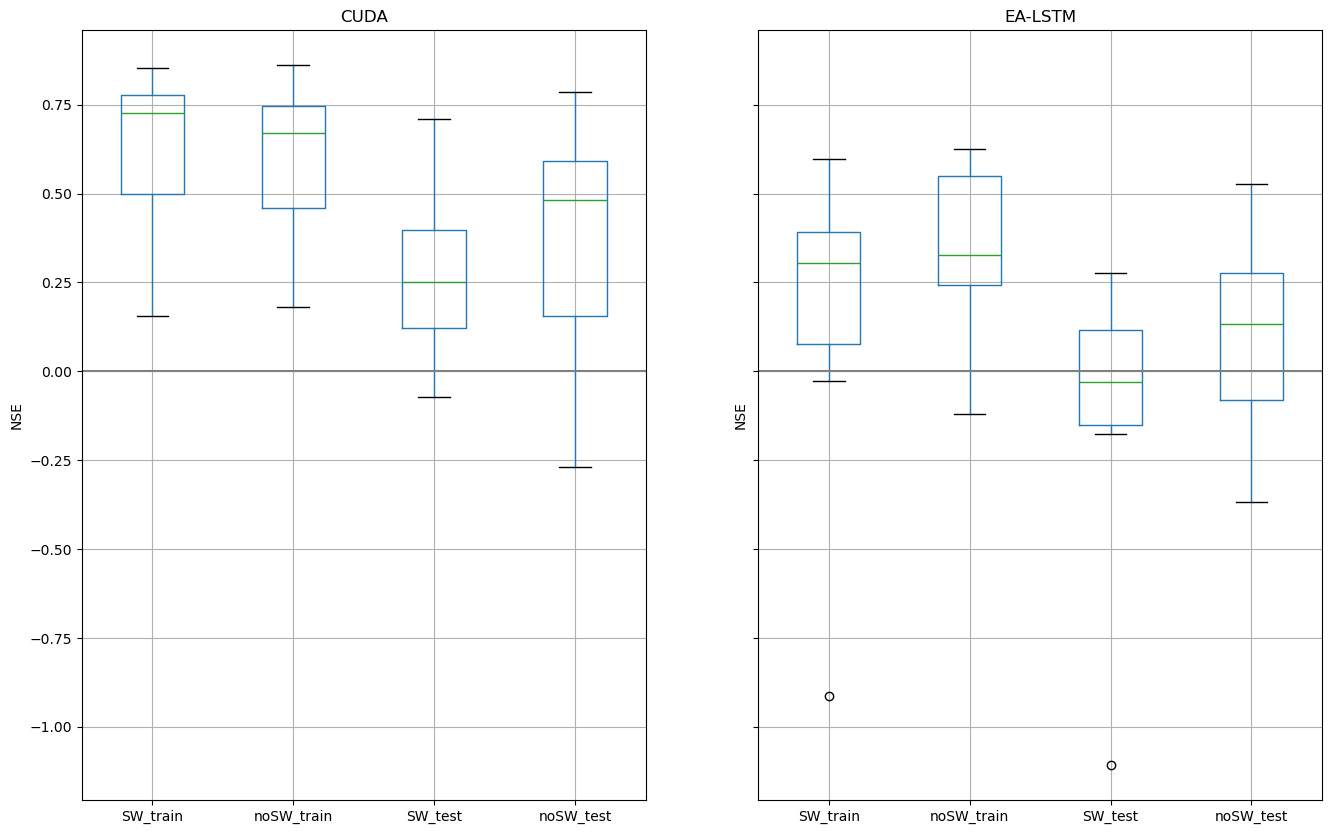

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10),sharey=True)
cuda_nse_df = comp_plots.boxplot_from_tuple(results_tuple_cuda,ax=axs[0],tuple_names=default_order,exp_name = 'CUDA')
ealstm_nse_df = comp_plots.boxplot_from_tuple(results_tuple_ealstm,ax=axs[1],tuple_names=default_order,exp_name = 'EA-LSTM')
# axs[0].set_ylim([-1.5,1])

In [10]:
cuda_nse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152450,5101500,5608096
SW_train,0.853501,0.792278,0.245906,0.438711,0.728246,0.726635,0.737572,0.154893,0.674968,0.832861
noSW_train,0.861235,0.755603,0.221657,0.420067,0.742471,0.728514,0.580774,0.181118,0.611649,0.746252
SW_test,0.257602,0.708705,-0.073090,0.016916,0.258546,0.463022,0.442902,0.080702,0.239743,0.245201
noSW_test,0.599764,0.785556,-0.070764,0.129073,0.236621,0.561493,0.623476,-0.269150,0.474313,0.491378


In [11]:
ealstm_nse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152450,5101500,5608096
SW_train,0.413237,-0.912934,0.057513,0.327910,0.317318,0.596352,0.290515,-0.026470,0.133975,0.422570
noSW_train,0.624323,-0.119035,0.228032,0.289592,0.535810,0.574417,0.361235,-0.016814,0.292471,0.552600
SW_test,-0.176380,-1.108047,-0.059326,-0.157762,0.123441,0.098668,0.000189,-0.127271,0.152724,0.275656
noSW_test,0.526036,-0.108069,-0.094633,0.094953,-0.367089,0.287430,0.516757,-0.042313,0.243989,0.172657


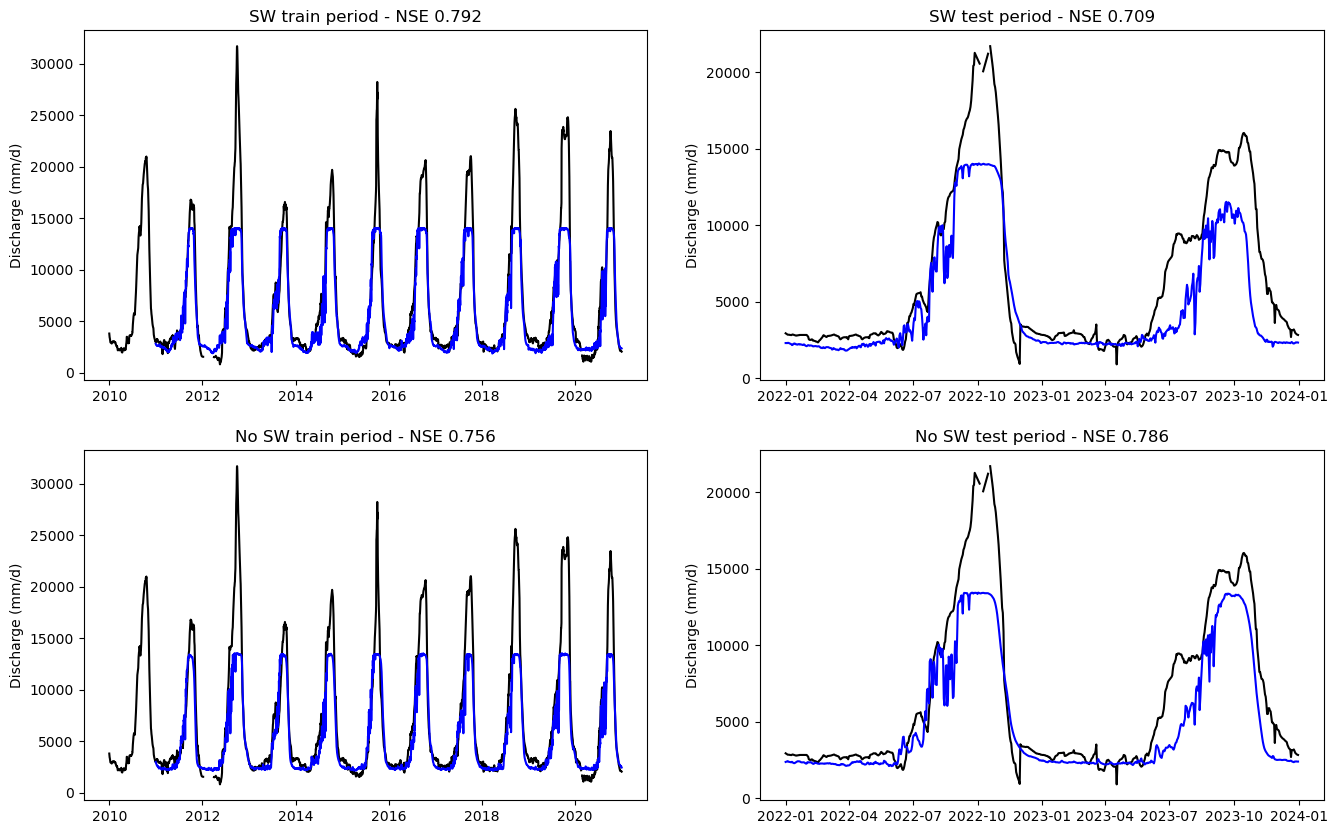

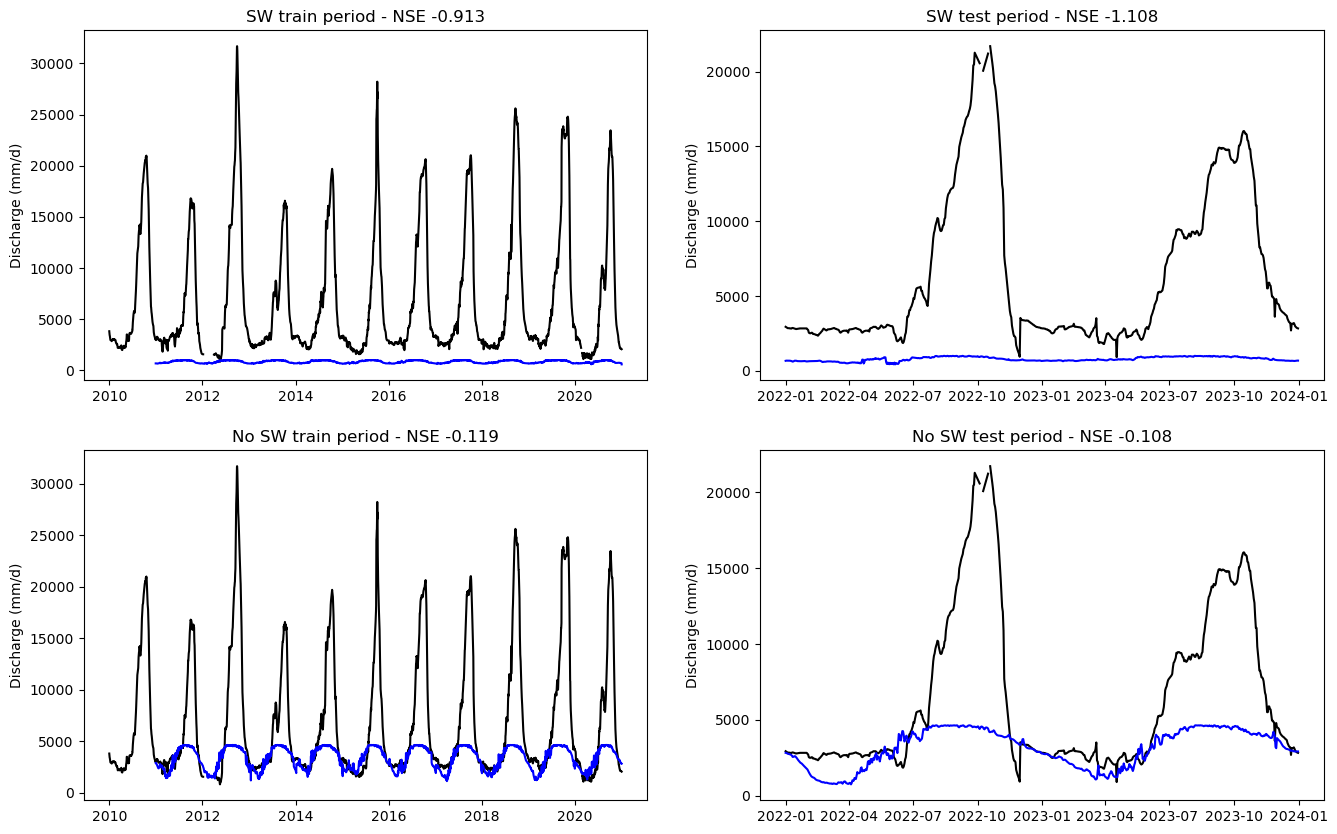

In [12]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = "1834101");
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key ="1834101");

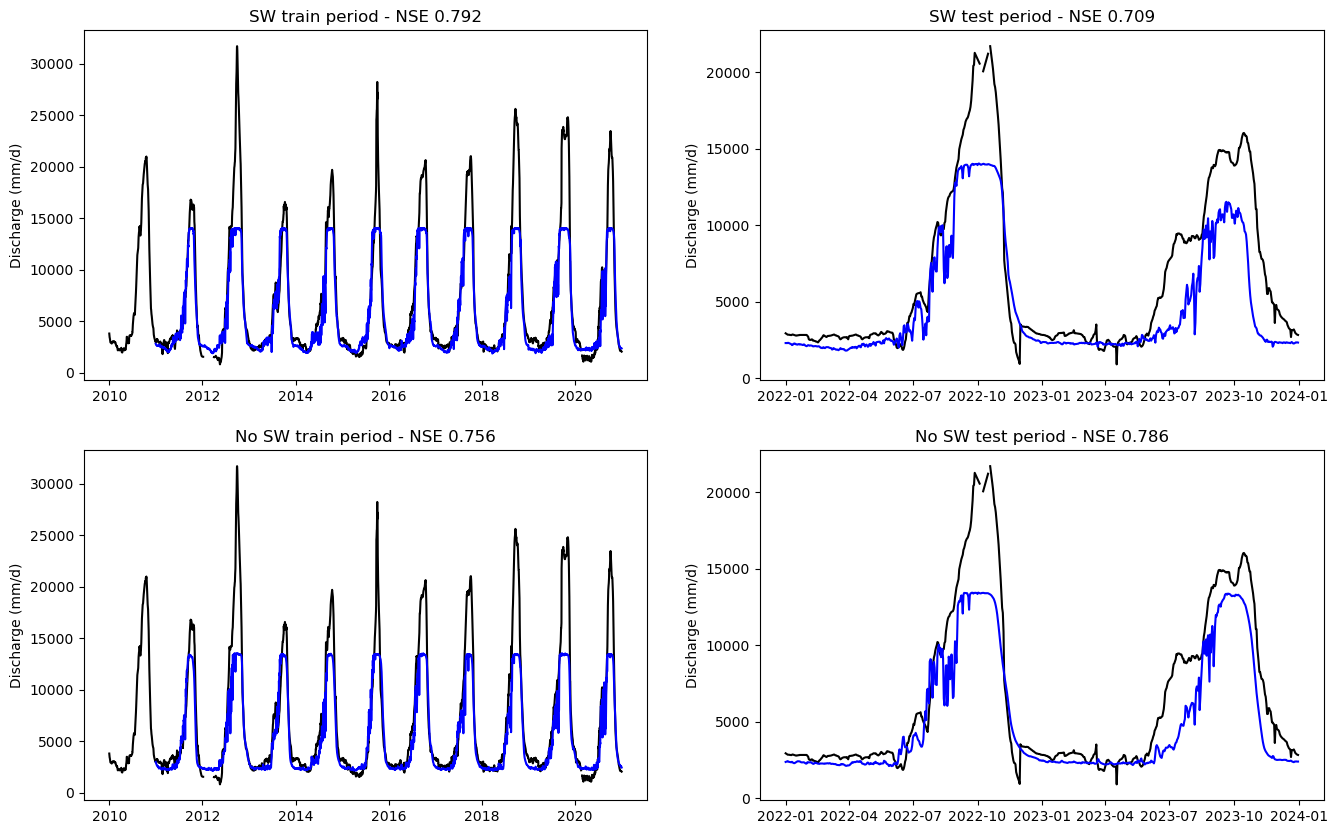

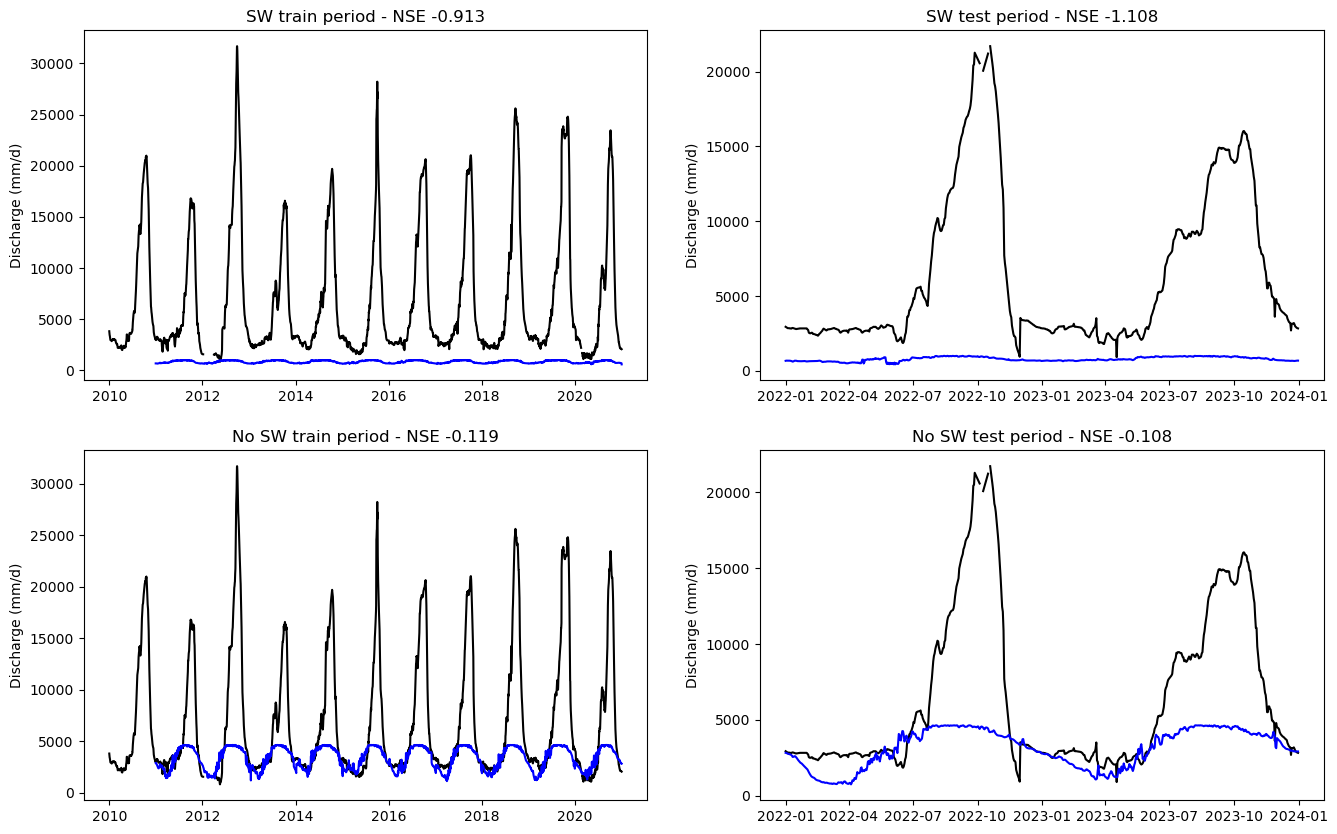

In [13]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[1]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[1]);

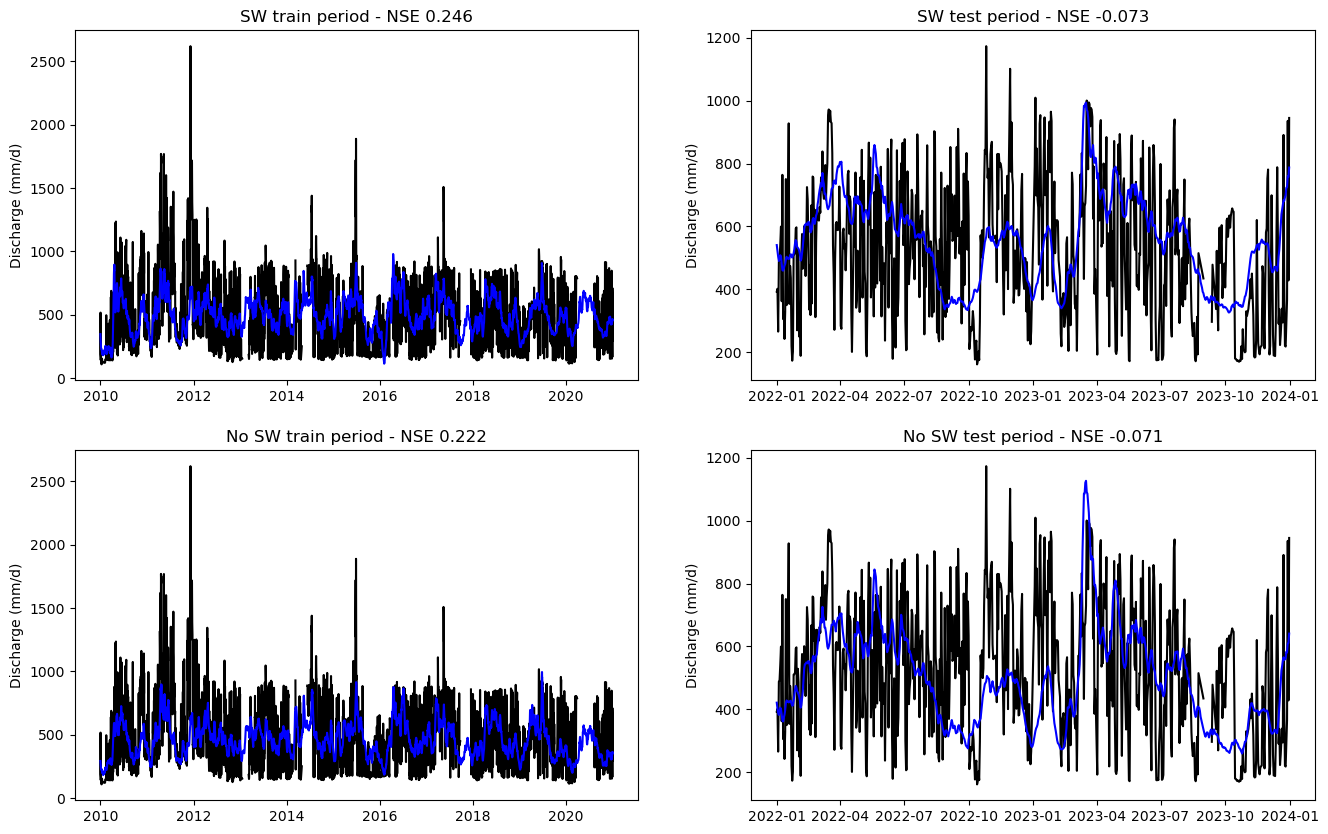

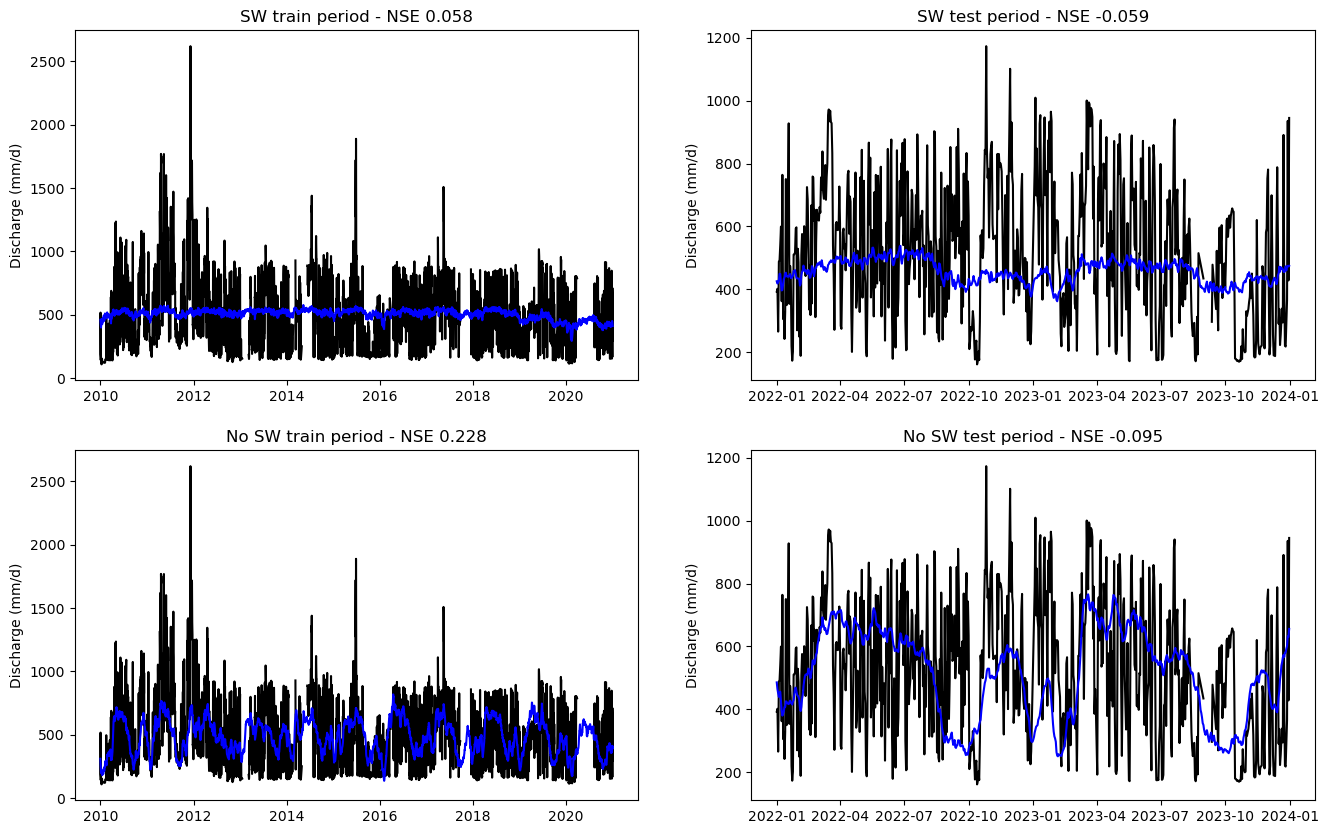

In [14]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[2]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[2]);

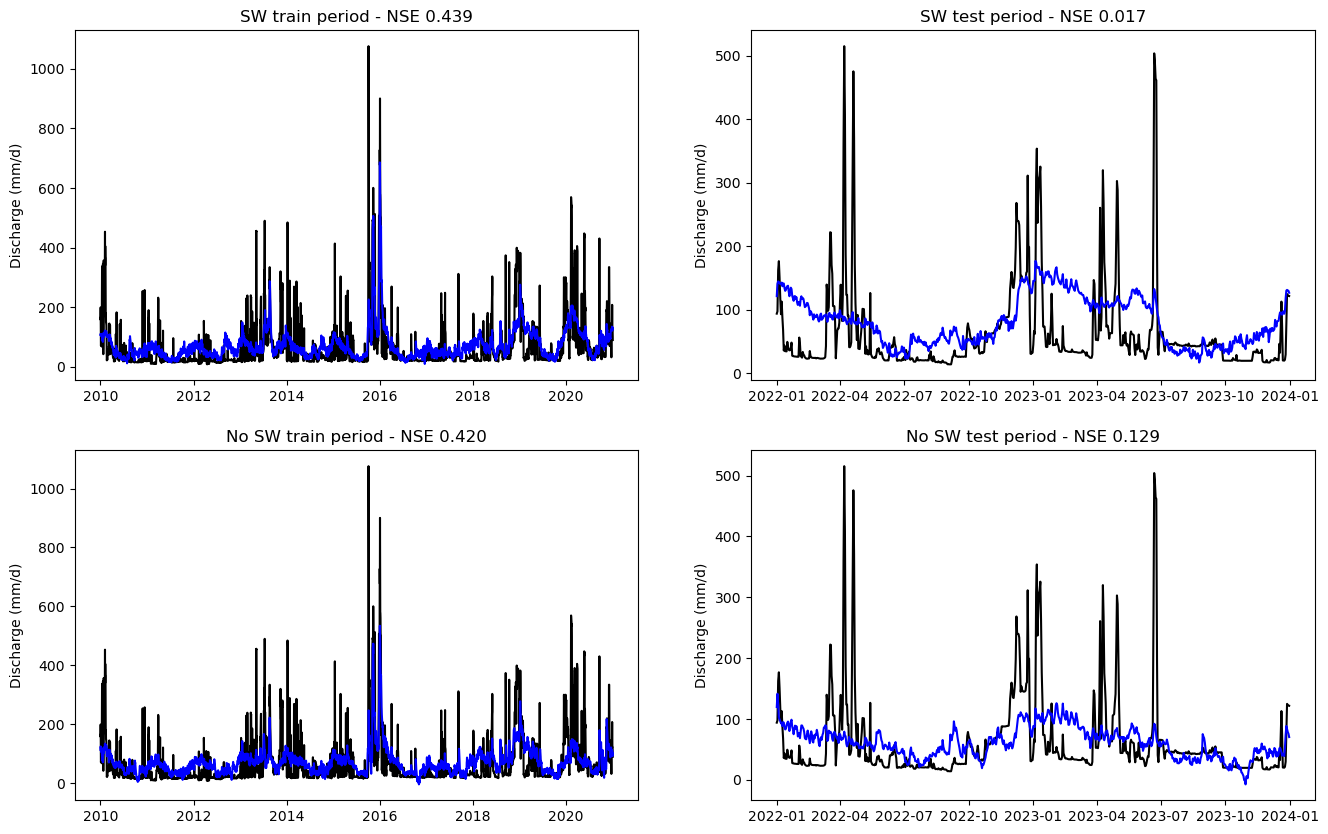

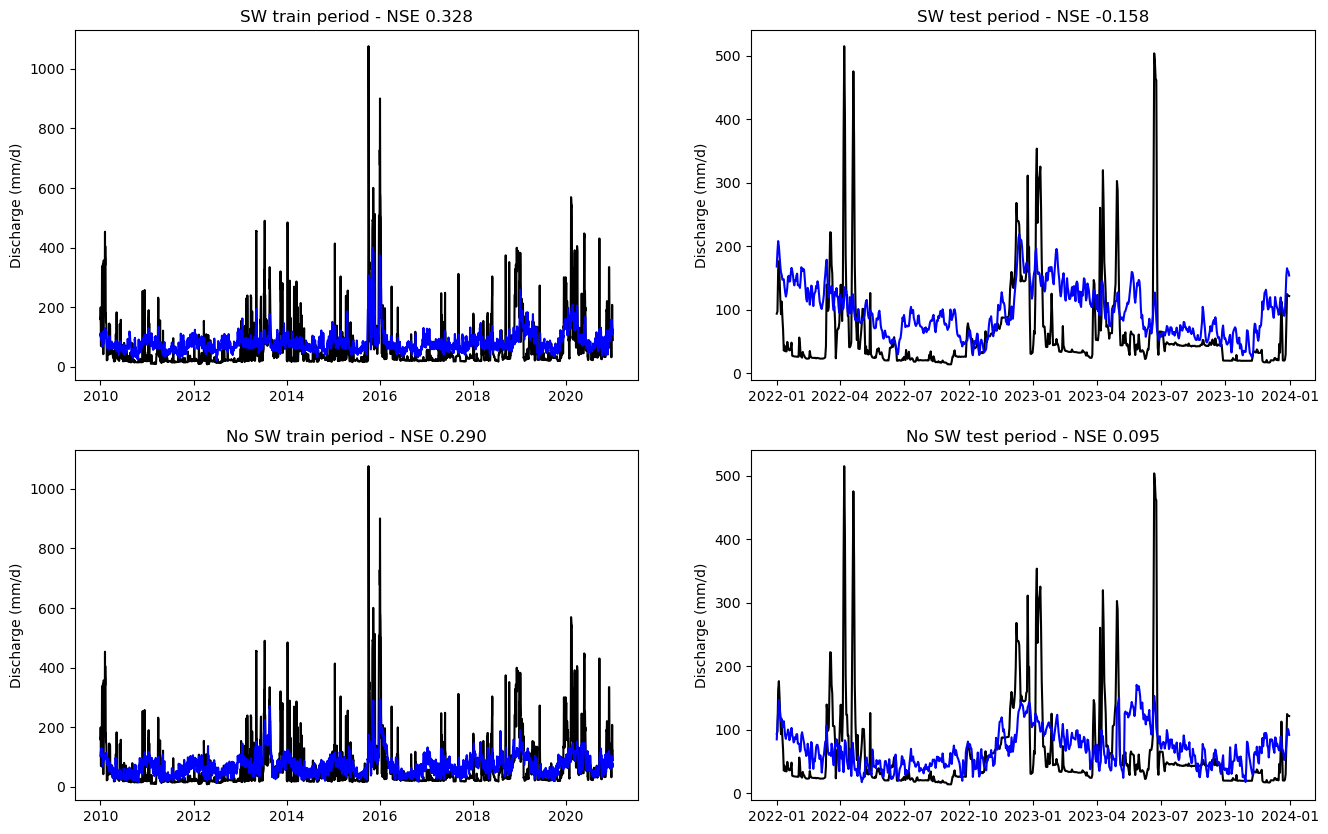

In [15]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[3]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[3]);

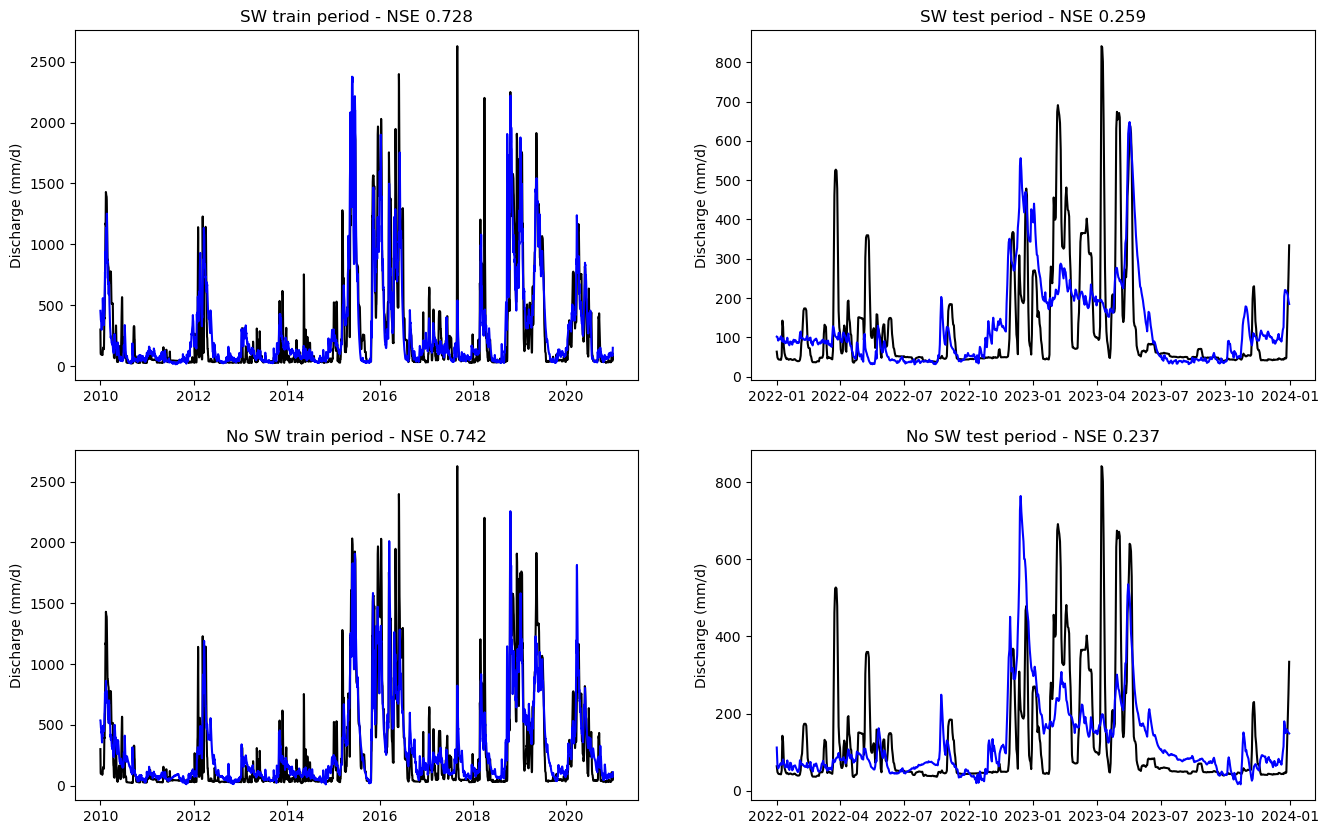

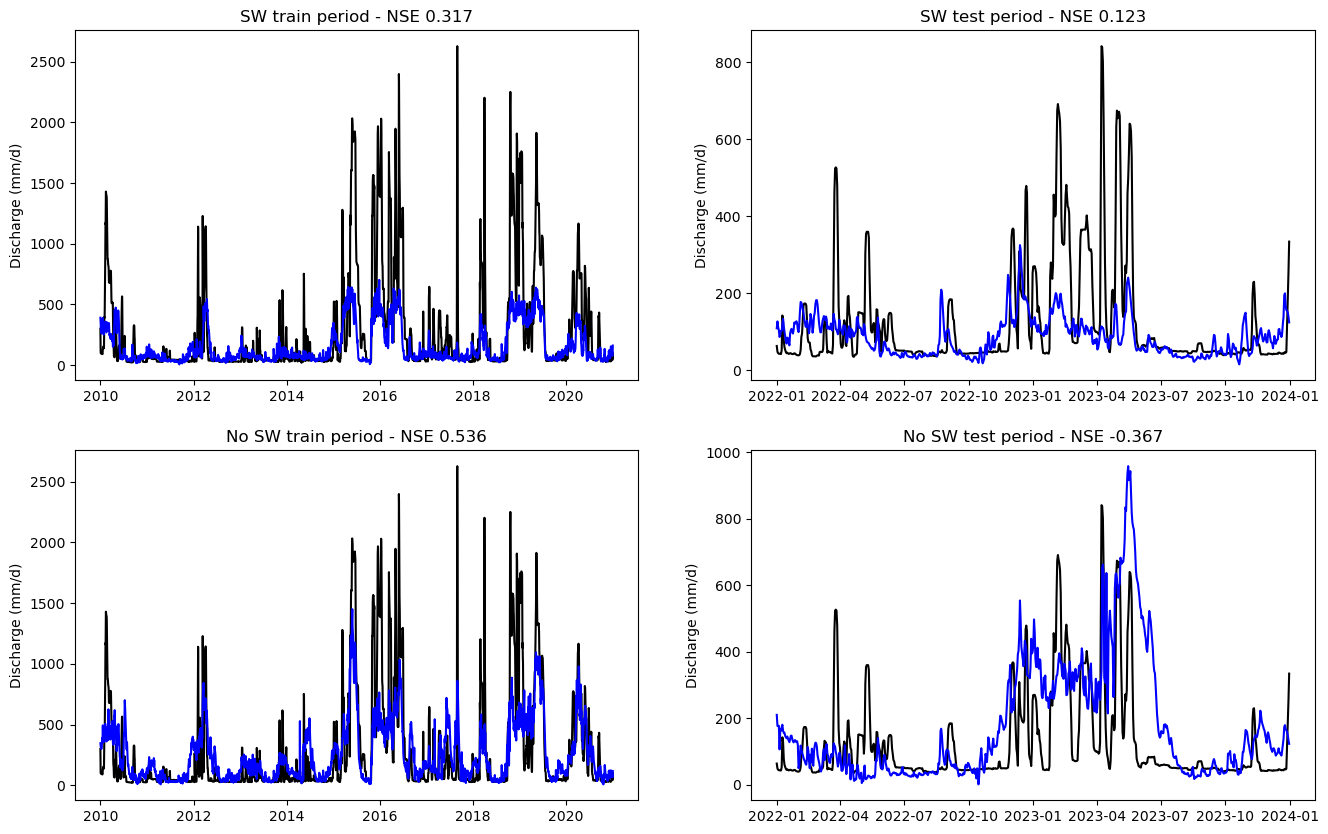

In [16]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[4]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[4]);

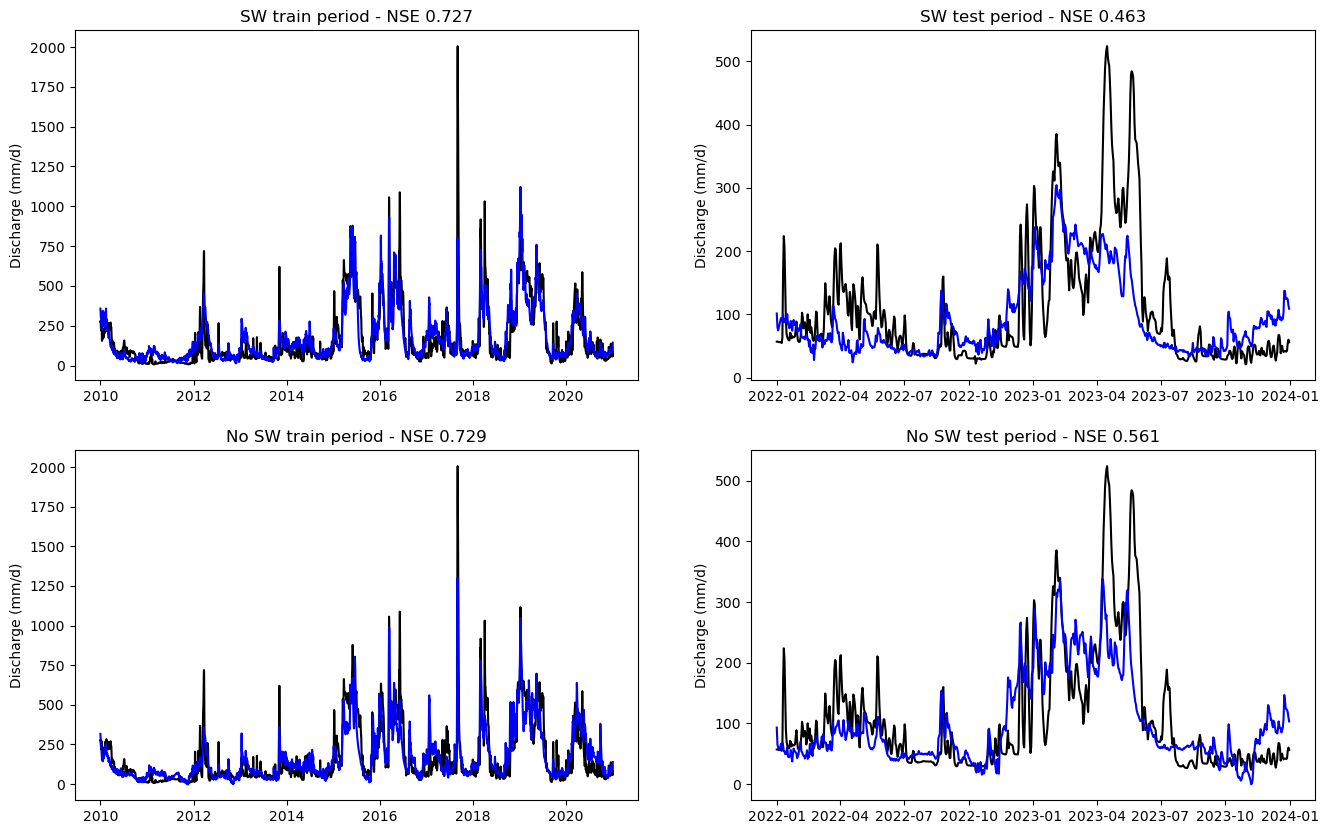

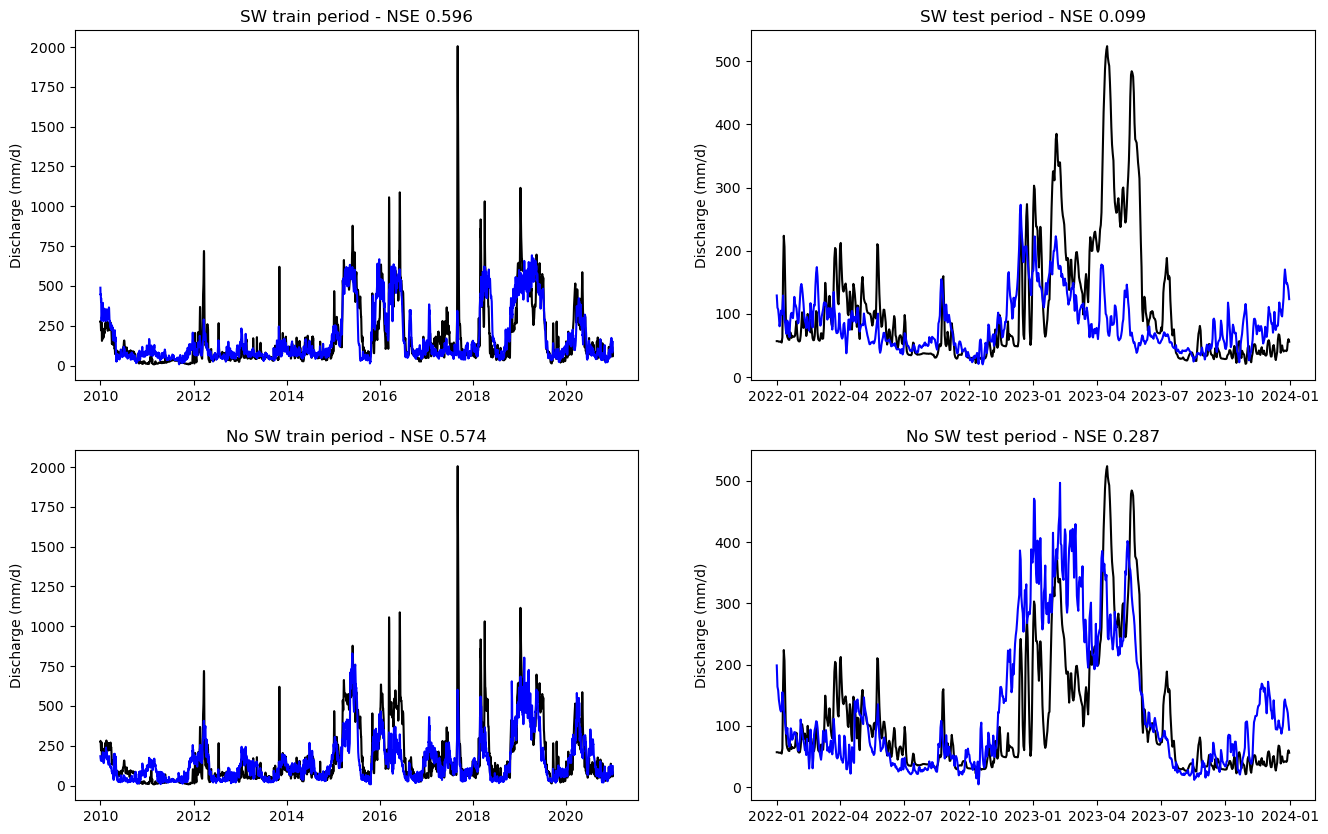

In [17]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[5]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[5]);